# CoSee — Market Data Analysis

This notebook is the main analysis workspace for the CoSee project.  
Data is loaded from the local Parquet cache in `data/raw/` (populated by `scripts/download_data.py`).

In [1]:
import sys
from pathlib import Path

# Make the cosee package importable from the notebook
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA_DIR = Path.cwd().parent / "data" / "raw"
print("Data directory:", DATA_DIR)
print("Available files:", len(list(DATA_DIR.glob("*.parquet"))))

Matplotlib is building the font cache; this may take a moment.


Data directory: /Users/mathieu26/Desktop/Projects/CoSee/data/raw
Available files: 35


## Load and Preview Data

In [2]:
def load_asset(ticker: str) -> pd.DataFrame:
    """Load a single asset from the local Parquet cache."""
    safe = ticker.replace("/", "_").replace("=", "_").replace("^", "_").replace("-", "_")
    path = DATA_DIR / f"{safe}.parquet"
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    return df

aapl = load_asset("AAPL")
print("AAPL shape:", aapl.shape)
aapl.head()

AAPL shape: (2878, 6)


Price,adj_close,close,high,low,open,volume
date,,,,,,
2015-01-02,24.192602,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.511053,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.513273,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.842985,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.759081,27.972500,28.037500,27.174999,27.307501,237458000


## Apple (AAPL) Closing Price

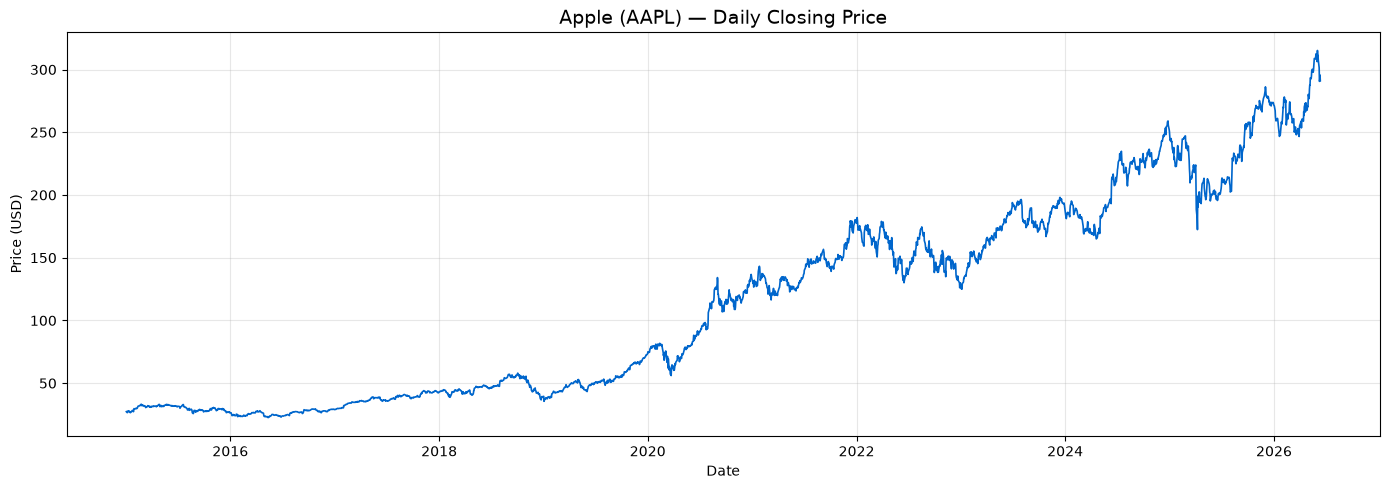

In [3]:
fig, ax = plt.subplots()
ax.plot(aapl.index, aapl["close"], linewidth=1.2, color="#0066cc", label="AAPL")
ax.set_title("Apple (AAPL) — Daily Closing Price", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## Gold Futures (GC=F) Closing Price

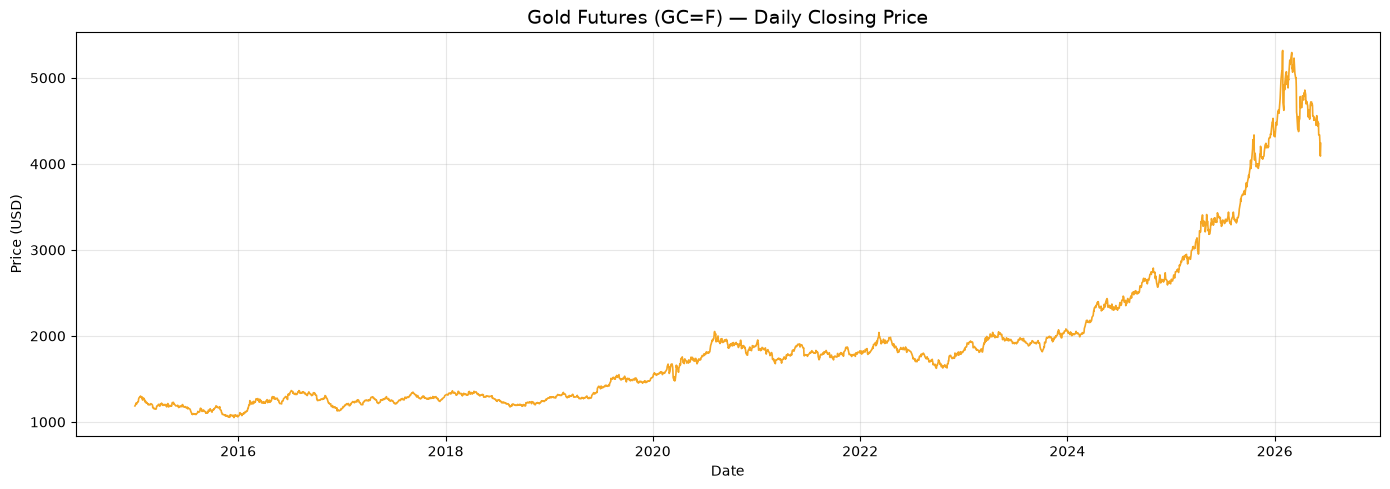

In [4]:
gold = load_asset("GC=F")

fig, ax = plt.subplots()
ax.plot(gold.index, gold["close"], linewidth=1.2, color="#f5a623", label="GC=F")
ax.set_title("Gold Futures (GC=F) — Daily Closing Price", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## AAPL vs Gold — Dual-Axis Comparison

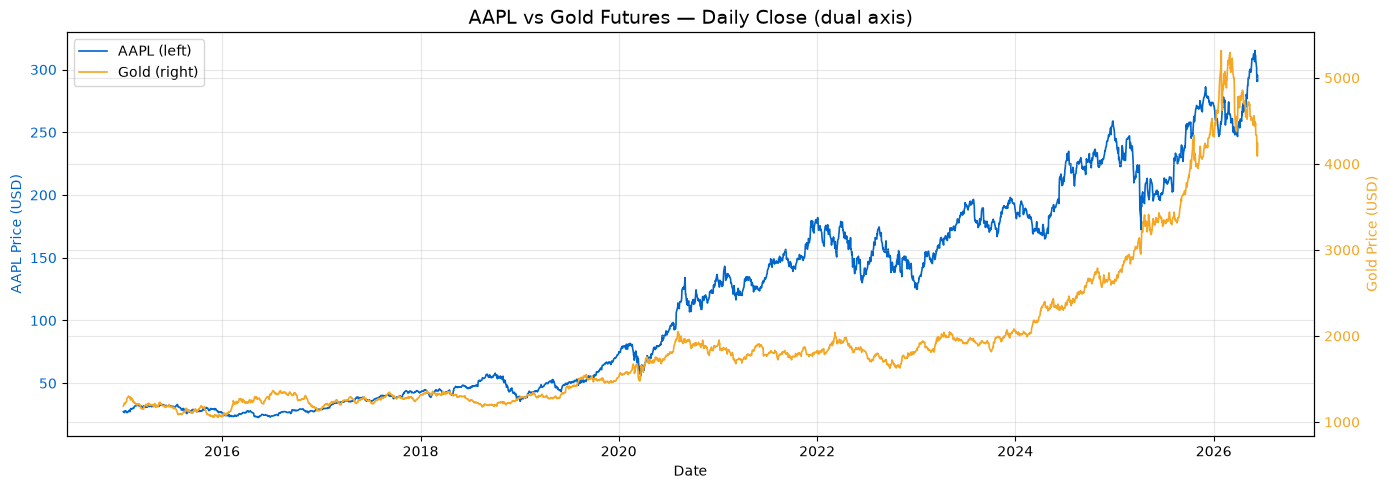

In [5]:
color_aapl = "#0066cc"
color_gold = "#f5a623"

common_idx = aapl.index.intersection(gold.index)
aapl_aligned = aapl.loc[common_idx, "close"]
gold_aligned = gold.loc[common_idx, "close"]

fig, ax1 = plt.subplots()

ax1.plot(common_idx, aapl_aligned, linewidth=1.2, color=color_aapl, label="AAPL (left)")
ax1.set_ylabel("AAPL Price (USD)", color=color_aapl)
ax1.tick_params(axis="y", labelcolor=color_aapl)

ax2 = ax1.twinx()
ax2.plot(common_idx, gold_aligned, linewidth=1.2, color=color_gold, label="Gold (right)")
ax2.set_ylabel("Gold Price (USD)", color=color_gold)
ax2.tick_params(axis="y", labelcolor=color_gold)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("AAPL vs Gold Futures — Daily Close (dual axis)", fontsize=14)
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## Normalised Performance (Base = 100)

Both assets rebased to 100 at the start of the period to compare **relative performance** on the same scale — removing the price-level difference.

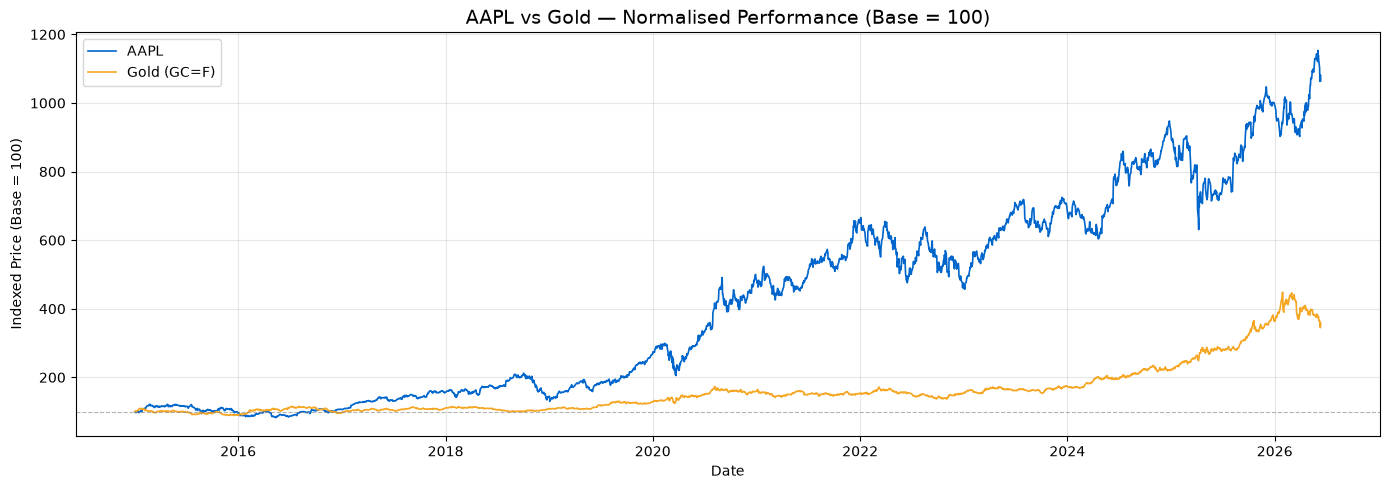

In [6]:
aapl_norm = aapl_aligned / aapl_aligned.iloc[0] * 100
gold_norm = gold_aligned / gold_aligned.iloc[0] * 100

fig, ax = plt.subplots()
ax.plot(common_idx, aapl_norm, linewidth=1.2, color=color_aapl, label="AAPL")
ax.plot(common_idx, gold_norm, linewidth=1.2, color=color_gold, label="Gold (GC=F)")
ax.axhline(100, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_title("AAPL vs Gold — Normalised Performance (Base = 100)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Price (Base = 100)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()